<a href="https://colab.research.google.com/github/runo313/Deep-Learning/blob/main/CNNs/VGG11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchsummary import summary
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [26]:
class VGG11(nn.Module):
  def __init__(self,eta=0.001,n_iter=30,batch_size=128,random_state=42):
    super().__init__()

    self.eta=eta
    self.n_iter = n_iter
    self.batch_size = batch_size
    self.random_state = random_state

    self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {self.device}')

    #Block 1 1 conv, 64 filters | 32x32 -> pool -> 16x16
    self.conv1=nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,stride=1,padding=1)
    self.pool1   = nn.MaxPool2d(kernel_size=2, stride=2)

    # Block 2: 1 conv, 128 filters | 16x16 -> pool -> 8x8
    self.conv2=nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=1,padding=1)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    # Block 3: 2 convs, 256 filters | 8x8 -> pool -> 4x4
    self.conv3_1=nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=1,padding=1)
    self.conv3_2=nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,stride=1,padding=1)
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    # Block 4: 2 convs, 512 filters | 4x4 -> NO pool
    self.conv4_1=nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,stride=1,padding=1)
    self.conv4_2=nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,stride=1,padding=1)

    # Block 5: 2 convs, 512 filters | 4x4 -> NO pool
    self.conv5_1=nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,stride=1,padding=1)
    self.conv5_2=nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,stride=1,padding=1)

    self.flatten = nn.Flatten()
    self.fc1     = nn.Linear(8192, 512)
    self.fc2     = nn.Linear(512, 256)
    self.output  = nn.Linear(256, 10)

    self.train_losses_     = []
    self.train_accuracies_ = []
    self.val_losses_       = []
    self.val_accuracies_   = []

    self.to(self.device)
    print(f"VGG-11 initialised on: {self.device}")

  def forward(self, x):
    x = self.pool1(torch.relu(self.conv1(x)))
    x = self.pool2(torch.relu(self.conv2(x)))
    x = torch.relu(self.conv3_1(x))
    x = self.pool3(torch.relu(self.conv3_2(x)))
    x = torch.relu(self.conv4_1(x))
    x = torch.relu(self.conv4_2(x))
    x = torch.relu(self.conv5_1(x))
    x = torch.relu(self.conv5_2(x))
    x = self.flatten(x)
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.output(x)
    return x

  def iter_minibatch(self, X, y):
        dataset    = TensorDataset(X, y)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        return dataloader

  def _evaluate(self, X, y, criterion):
        loader = self.iter_minibatch(X, y)
        self.eval()

        running_loss = 0.0
        correct      = 0
        total        = 0

        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                outputs = self(X_batch)
                loss    = criterion(outputs, y_batch)

                running_loss += loss.item()
                _, predicted  = torch.max(outputs, dim=1)
                total        += y_batch.size(0)
                correct      += (predicted == y_batch).sum().item()

        avg_loss = running_loss / len(loader)
        accuracy = 100.0 * correct / total
        return avg_loss, accuracy

  def predict(self, X):
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        self.eval()
        with torch.no_grad():
            X        = X.to(self.device)
            logits   = self(X)
            _, preds = torch.max(logits, dim=1)
        return preds.cpu().numpy()
  def accuracy(self, X, y):
        if isinstance(y, torch.Tensor):
            y = y.numpy()
        preds = self.predict(X)
        return 100.0 * np.mean(preds == y)

  def fit(self, X, y, X_val, y_val):
        torch.manual_seed(self.random_state)
        optimizer    = optim.SGD(self.parameters(), lr=self.eta,
                                 momentum=0.9, weight_decay=1e-4)
        criterion    = nn.CrossEntropyLoss()
        train_loader = self.iter_minibatch(X, y)

        for epoch in range(self.n_iter):
            self.train()

            running_loss = 0.0
            correct      = 0
            total        = 0

            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                optimizer.zero_grad()
                y_hat = self(X_batch)
                loss  = criterion(y_hat, y_batch)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds         = y_hat.argmax(dim=1)
                correct      += (preds == y_batch).sum().item()
                total        += y_batch.size(0)

            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total

            self.train_losses_.append(epoch_loss)
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_val, y_val, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        return self


In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=test_transform)

# ── Split trainset → 45k train / 5k val ──────────────────────────────────────
train_size = 45000
val_size   = 5000

train_subset, val_subset = random_split(
    trainset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
def dataset_to_tensors(subset):
    """Load an entire Dataset subset into memory as tensors."""
    loader = DataLoader(subset, batch_size=len(subset), shuffle=False)
    X, y = next(iter(loader))   # one giant batch = the whole subset
    return X, y

print("Loading train tensors...")
X_train, y_train = dataset_to_tensors(train_subset)

print("Loading val tensors...")
X_val, y_val     = dataset_to_tensors(val_subset)

print("Loading test tensors...")
X_test, y_test   = dataset_to_tensors(testset)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

100%|██████████| 170M/170M [00:09<00:00, 17.6MB/s]


Loading train tensors...
Loading val tensors...
Loading test tensors...
Train: torch.Size([45000, 3, 32, 32]) | Val: torch.Size([5000, 3, 32, 32]) | Test: torch.Size([10000, 3, 32, 32])


In [12]:
model_a=VGG11(eta=0.001,n_iter=100,batch_size=128,random_state=42)
model_a.fit(X_train,y_train,X_val,y_val)
test_acc = model_a.accuracy(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

Using device: cuda
VGG-11 initialised on: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         MaxPool2d-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 256, 8, 8]         295,168
            Conv2d-6            [-1, 256, 8, 8]         590,080
         MaxPool2d-7            [-1, 256, 4, 4]               0
            Conv2d-8            [-1, 512, 4, 4]       1,180,160
            Conv2d-9            [-1, 512, 4, 4]       2,359,808
           Conv2d-10            [-1, 512, 4, 4]       2,359,808
           Conv2d-11            [-1, 512, 4, 4]       2,359,808
          Flatten-12                 [-1, 8192]               0
           Linear-13                  [-1, 512]       4,

In [13]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()
  print("Saved: training_curves.png")



In [14]:
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def plot_confusion_matrix(model, X_test, y_test, title='Confusion Matrix — AlexNet CIFAR-10 (Part A)'):
    # Get predictions from the model
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,           # show counts in each cell
        fmt='d',              # integer format
        cmap='Blues',         # blue colormap — darker = more examples
        xticklabels=CIFAR10_CLASSES,
        yticklabels=CIFAR10_CLASSES,
        linewidths=0.5,
        linecolor='gray',
        ax=ax
    )

    ax.set_xlabel('Predicted label', fontsize=12, labelpad=10)
    ax.set_ylabel('True label', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Rotate x-axis labels so they don't overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

    # ── Print per-class accuracy ───────────────────────────────────────────
    print("\nPer-class accuracy:")
    print("-" * 35)
    for i, class_name in enumerate(CIFAR10_CLASSES):
        class_total   = cm[i].sum()
        class_correct = cm[i, i]
        class_acc     = 100.0 * class_correct / class_total
        print(f"  {class_name:<12}: {class_correct:>4}/{class_total} = {class_acc:.1f}%")
    print("-" * 35)
    overall = 100.0 * np.diag(cm).sum() / cm.sum()
    print(f"  {'Overall':<12}: {overall:.2f}%")

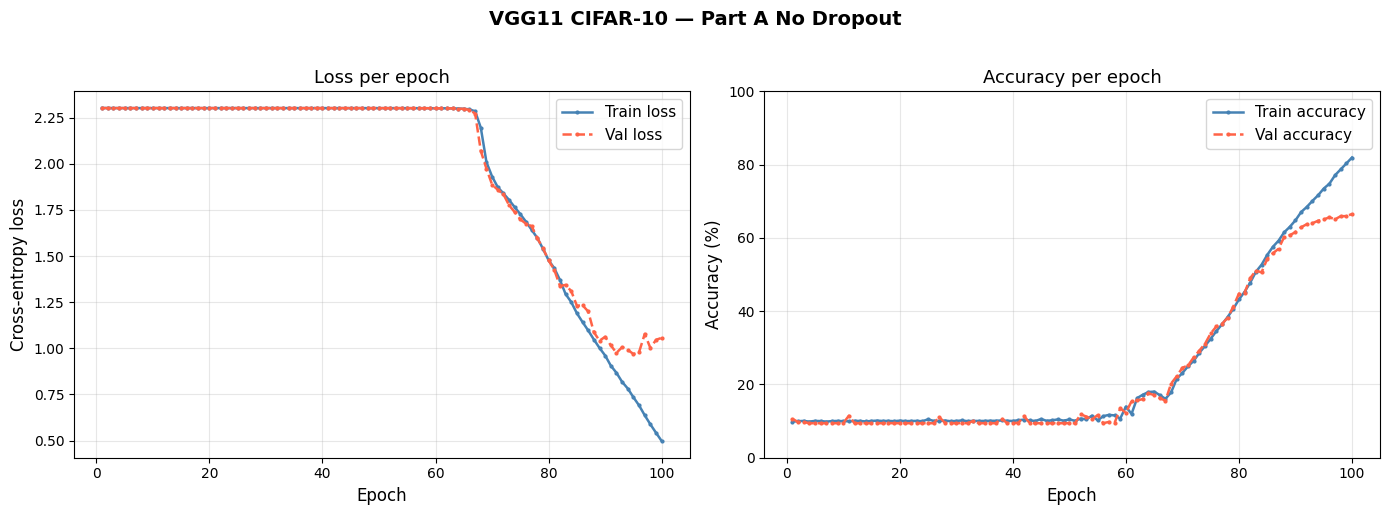

Saved: training_curves.png


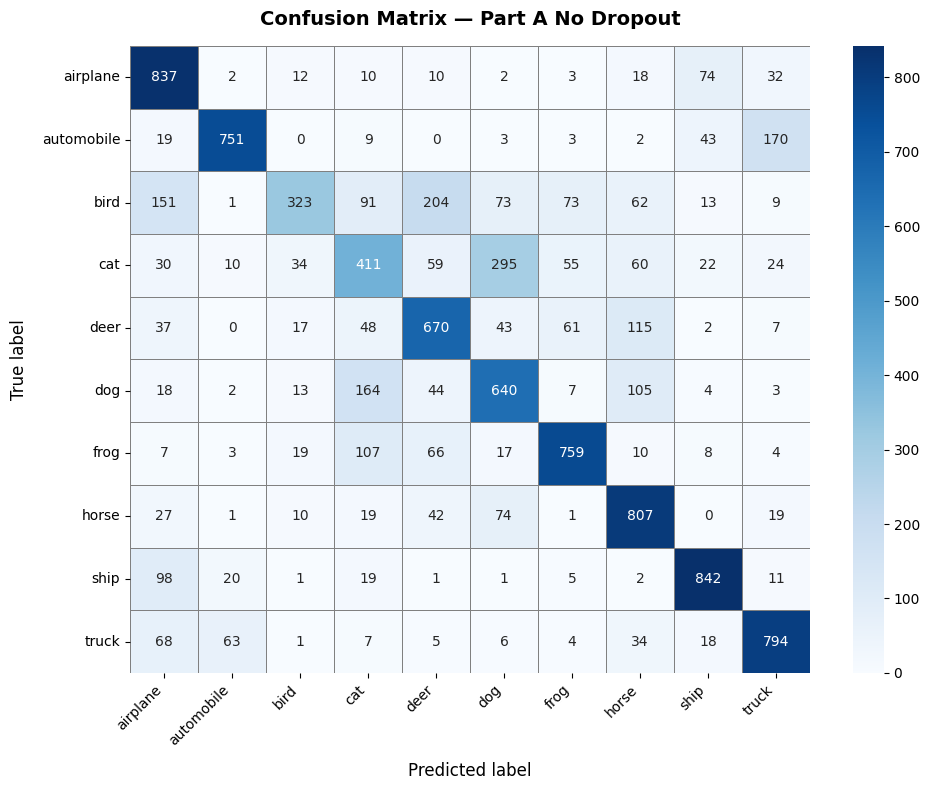

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  837/1000 = 83.7%
  automobile  :  751/1000 = 75.1%
  bird        :  323/1000 = 32.3%
  cat         :  411/1000 = 41.1%
  deer        :  670/1000 = 67.0%
  dog         :  640/1000 = 64.0%
  frog        :  759/1000 = 75.9%
  horse       :  807/1000 = 80.7%
  ship        :  842/1000 = 84.2%
  truck       :  794/1000 = 79.4%
-----------------------------------
  Overall     : 68.34%


In [15]:
plot_curves(model_a, title='VGG11 CIFAR-10 — Part A No Dropout')

plot_confusion_matrix(model_a, X_test, y_test,
                      title='Confusion Matrix — Part A No Dropout')

In [27]:
class VGG11Dropout(VGG11):
    def __init__(self, eta=0.001, n_iter=100, batch_size=128,
                 random_state=42, dropout_rate=0.5):
        super().__init__(eta, n_iter, batch_size, random_state)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.dropout_rate = dropout_rate
        print(f"Dropout rate: {dropout_rate}")

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = torch.relu(self.conv3_1(x))
        x = self.pool3(torch.relu(self.conv3_2(x)))
        x = torch.relu(self.conv4_1(x))
        x = torch.relu(self.conv4_2(x))
        x = torch.relu(self.conv5_1(x))
        x = torch.relu(self.conv5_2(x))
        x = self.flatten(x)
        x = self.dropout(torch.relu(self.fc1(x)))    # dropout after fc1
        x = self.dropout(torch.relu(self.fc2(x)))    # dropout after fc2
        x = self.output(x)
        return x

In [29]:
vgg_d3 = VGG11Dropout(eta=0.001, n_iter=100, batch_size=128,
                       random_state=42, dropout_rate=0.3)
summary(vgg_d3, (3, 32, 32))
vgg_d3.fit(X_train, y_train, X_val, y_val)

Using device: cuda
VGG-11 initialised on: cuda
Dropout rate: 0.3
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         MaxPool2d-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 256, 8, 8]         295,168
            Conv2d-6            [-1, 256, 8, 8]         590,080
         MaxPool2d-7            [-1, 256, 4, 4]               0
            Conv2d-8            [-1, 512, 4, 4]       1,180,160
            Conv2d-9            [-1, 512, 4, 4]       2,359,808
           Conv2d-10            [-1, 512, 4, 4]       2,359,808
           Conv2d-11            [-1, 512, 4, 4]       2,359,808
          Flatten-12                 [-1, 8192]               0
           Linear-13                  

VGG11Dropout(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4_1): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4_2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5_2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=8192, out_feat

In [30]:
vgg_d5 = VGG11Dropout(eta=0.001, n_iter=100, batch_size=128,
                       random_state=42, dropout_rate=0.5)
vgg_d5.fit(X_train, y_train, X_val, y_val)

Using device: cuda
VGG-11 initialised on: cuda
Dropout rate: 0.5
Epoch   1/100 | Loss: 2.3030 | Acc: 10.19% | Val Loss: 2.3029 | Val Acc: 9.42%
Epoch   2/100 | Loss: 2.3028 | Acc: 9.90% | Val Loss: 2.3032 | Val Acc: 9.42%
Epoch   3/100 | Loss: 2.3028 | Acc: 9.98% | Val Loss: 2.3028 | Val Acc: 9.42%
Epoch   4/100 | Loss: 2.3026 | Acc: 10.19% | Val Loss: 2.3028 | Val Acc: 9.42%
Epoch   5/100 | Loss: 2.3027 | Acc: 9.92% | Val Loss: 2.3028 | Val Acc: 9.42%
Epoch   6/100 | Loss: 2.3027 | Acc: 10.15% | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch   7/100 | Loss: 2.3026 | Acc: 10.07% | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch   8/100 | Loss: 2.3027 | Acc: 10.06% | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch   9/100 | Loss: 2.3026 | Acc: 10.19% | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch  10/100 | Loss: 2.3026 | Acc: 9.79% | Val Loss: 2.3028 | Val Acc: 9.42%
Epoch  11/100 | Loss: 2.3026 | Acc: 9.92% | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch  12/100 | Loss: 2.3026 | Acc: 10.24% | Val Loss: 2.3026 | Val Acc

VGG11Dropout(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4_1): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4_2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5_2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=8192, out_feat

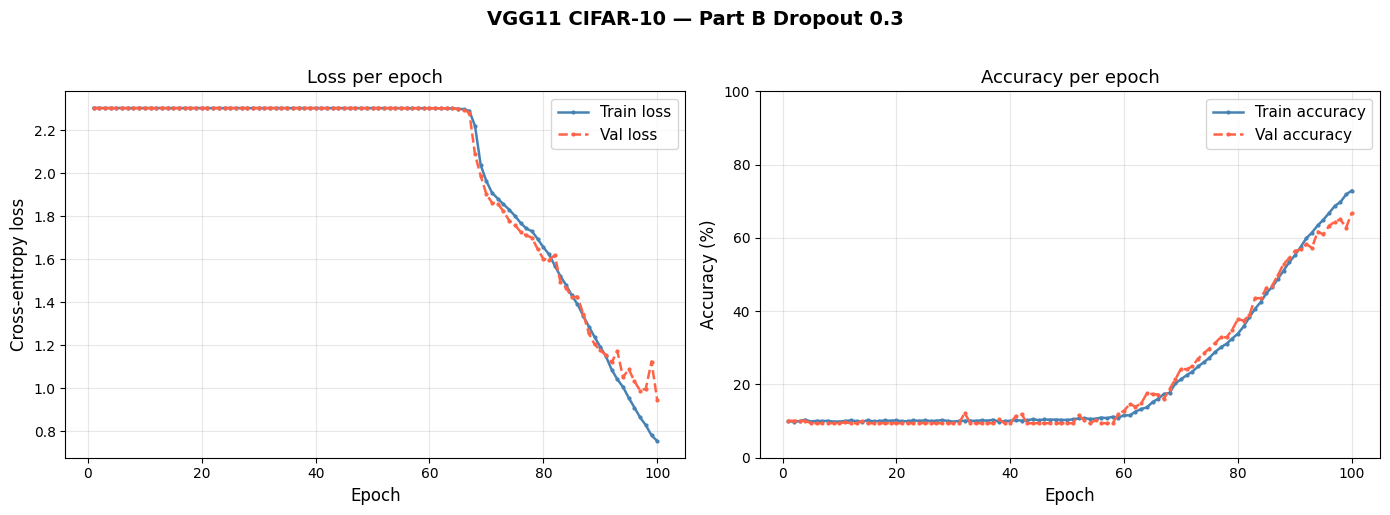

Saved: training_curves.png


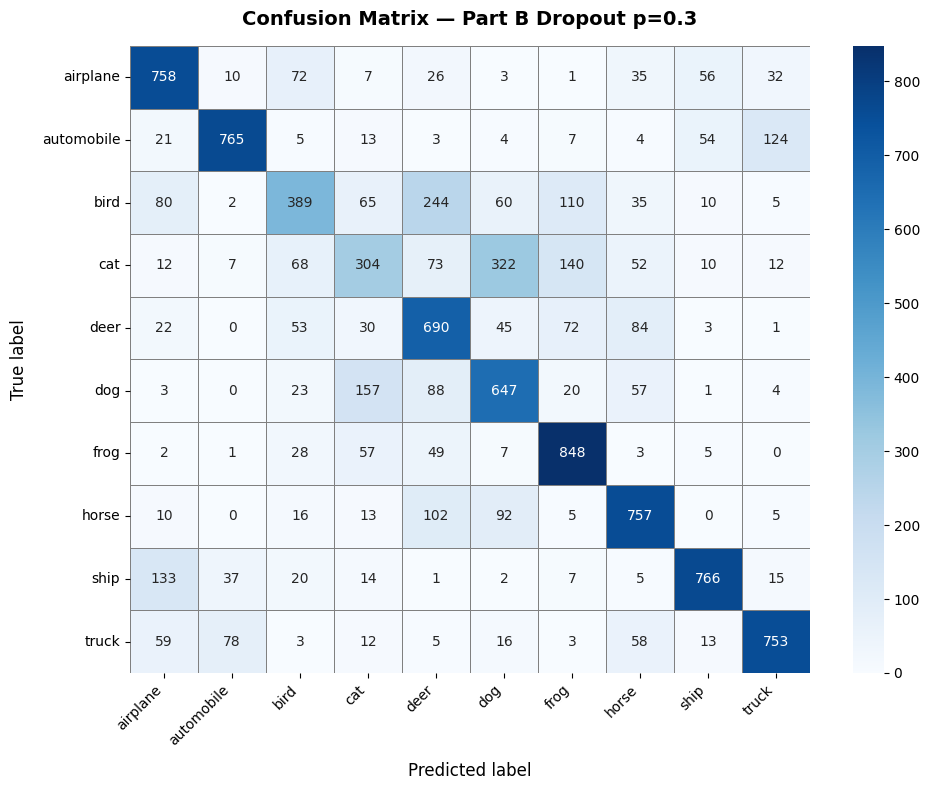

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  758/1000 = 75.8%
  automobile  :  765/1000 = 76.5%
  bird        :  389/1000 = 38.9%
  cat         :  304/1000 = 30.4%
  deer        :  690/1000 = 69.0%
  dog         :  647/1000 = 64.7%
  frog        :  848/1000 = 84.8%
  horse       :  757/1000 = 75.7%
  ship        :  766/1000 = 76.6%
  truck       :  753/1000 = 75.3%
-----------------------------------
  Overall     : 66.77%


In [31]:
plot_curves(vgg_d3, title='VGG11 CIFAR-10 — Part B Dropout 0.3')
plot_confusion_matrix(vgg_d3, X_test, y_test,title='Confusion Matrix — Part B Dropout p=0.3')

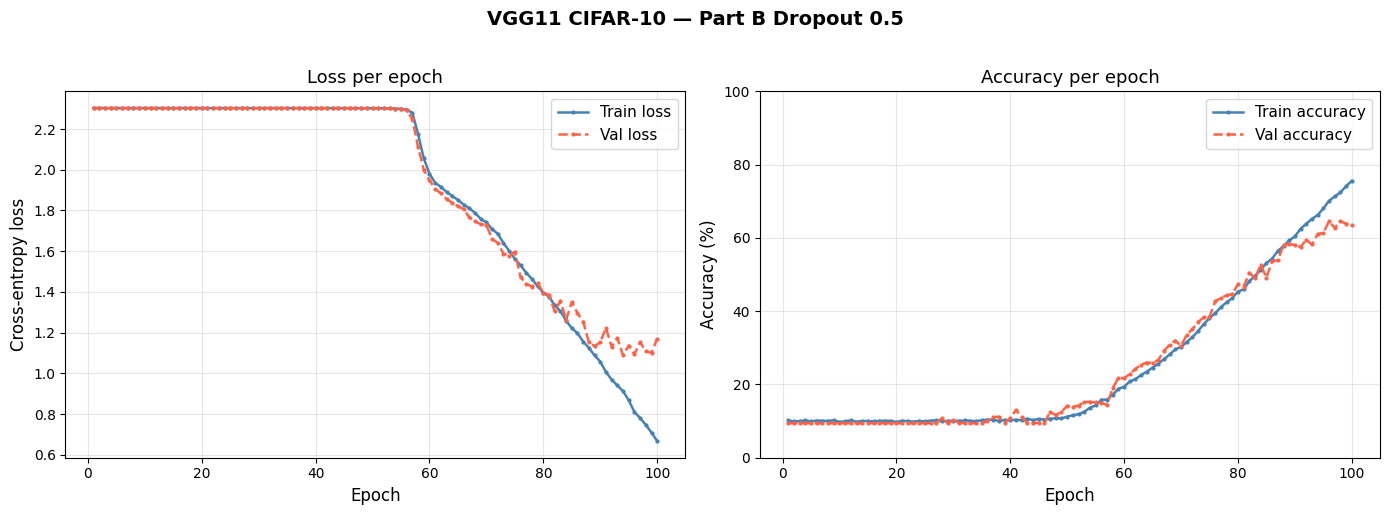

Saved: training_curves.png


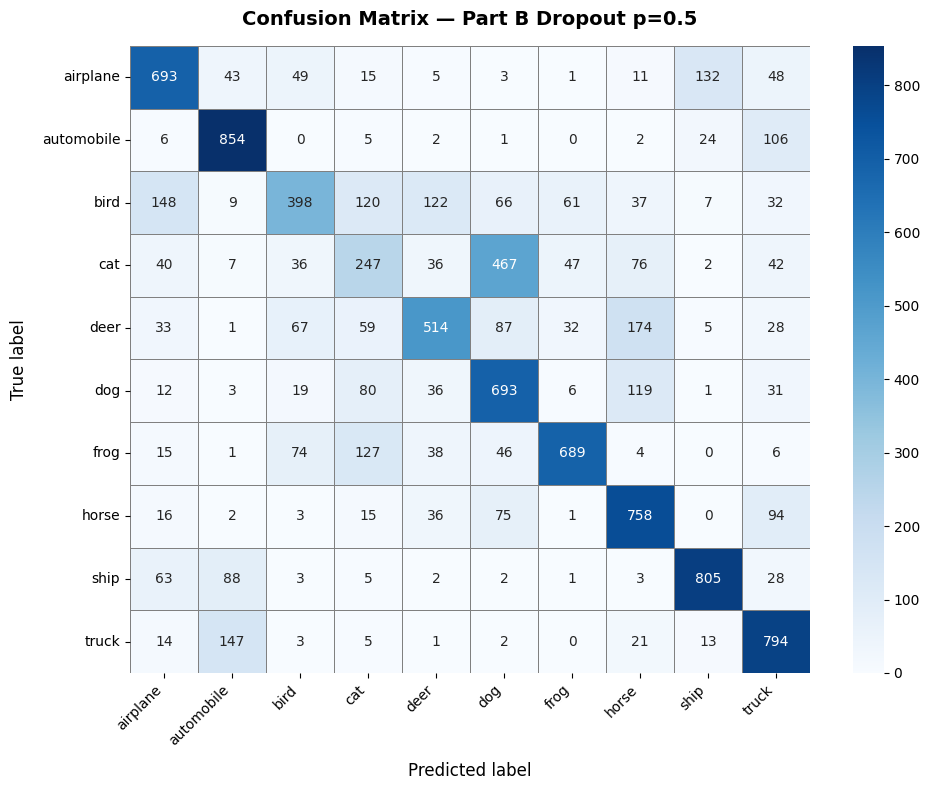

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  693/1000 = 69.3%
  automobile  :  854/1000 = 85.4%
  bird        :  398/1000 = 39.8%
  cat         :  247/1000 = 24.7%
  deer        :  514/1000 = 51.4%
  dog         :  693/1000 = 69.3%
  frog        :  689/1000 = 68.9%
  horse       :  758/1000 = 75.8%
  ship        :  805/1000 = 80.5%
  truck       :  794/1000 = 79.4%
-----------------------------------
  Overall     : 64.45%


In [32]:
plot_curves(vgg_d5, title='VGG11 CIFAR-10 — Part B Dropout 0.5')
plot_confusion_matrix(vgg_d5, X_test, y_test,title='Confusion Matrix — Part B Dropout p=0.5')